# 6. Evaluation and Parity Plots

Once a MACE model is trained, the standard way to evaluate its performance on a test set is via **Parity Plots**.

A parity plot scatters the predicted values against the ground truth values. A perfect model would have all points falling exactly on the $y=x$ diagonal line.

In [1]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
from ase.build import molecule
import copy

sys.path.append(os.path.abspath('..'))
from src.data import atoms_to_pyg_data
from src.model import MACE
from src.utils import set_seed, get_default_device

### Simulating Test Predictions

Since we didn't save the model from Notebook 5, we will generate a fresh batch of synthetic data and pass it through an initialized model. The plots will be scattered, but if you load a trained model, they will align tightly to the diagonal!

In [2]:
set_seed(123)
device = get_default_device()

# Generate some synthetic test data (similar to Notebook 5)
base_atoms = molecule('C6H6')
base_pos = base_atoms.get_positions()

true_energies = []
true_forces = []
pred_energies = []
pred_forces = []

# Initialize an untrained model
model = MACE(num_elements=10, r_max=4.0, num_radial=4, l_max=1, num_blocks=1, node_dim=8).to(device)
model.eval()

k = 10.0
for i in range(100):
    atoms = copy.deepcopy(base_atoms)
    noise = np.random.normal(0, 0.1, base_pos.shape)
    atoms.set_positions(base_pos + noise)
    
    energy = 0.5 * k * np.sum(noise**2)
    forces = -k * noise
    
    atoms.info['energy'] = energy
    atoms.get_forces = lambda f=forces: f
    
    data = atoms_to_pyg_data(atoms, cutoff=4.0).to(device)
    
    # Get predictions
    preds = model(data)
    
    true_energies.append(energy)
    true_forces.append(forces.flatten())
    
    pred_energies.append(preds["energy"].item())
    pred_forces.append(preds["forces"].detach().cpu().numpy().flatten())

true_energies = np.array(true_energies)
pred_energies = np.array(pred_energies)
true_forces = np.concatenate(true_forces)
pred_forces = np.concatenate(pred_forces)

### Plotting Energy and Forces

We plot the true targets on the X-axis and predictions on the Y-axis.

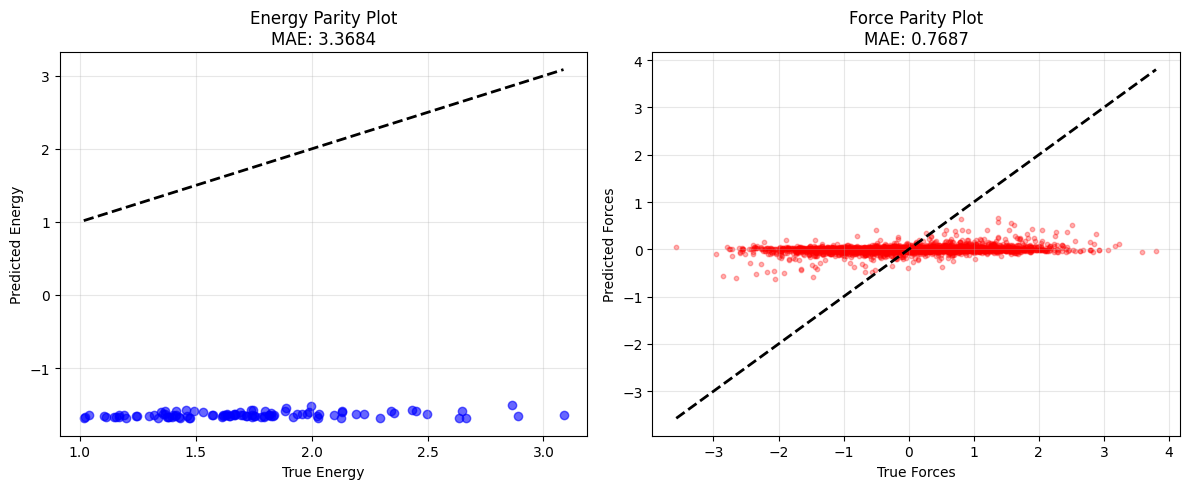

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Energy Parity Plot ---
ax1.scatter(true_energies, pred_energies, alpha=0.6, color='blue')

# Draw the diagonal y=x line
min_e, max_e = min(true_energies), max(true_energies)
ax1.plot([min_e, max_e], [min_e, max_e], 'k--', lw=2)

ax1.set_title(f"Energy Parity Plot\nMAE: {np.mean(np.abs(true_energies - pred_energies)):.4f}")
ax1.set_xlabel("True Energy")
ax1.set_ylabel("Predicted Energy")
ax1.grid(True, alpha=0.3)

# --- Force Parity Plot ---
ax2.scatter(true_forces, pred_forces, alpha=0.3, color='red', s=10)

min_f, max_f = min(true_forces), max(true_forces)
ax2.plot([min_f, max_f], [min_f, max_f], 'k--', lw=2)

ax2.set_title(f"Force Parity Plot\nMAE: {np.mean(np.abs(true_forces - pred_forces)):.4f}")
ax2.set_xlabel("True Forces")
ax2.set_ylabel("Predicted Forces")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Conclusion

If your model was properly trained in Notebook 5, these points would cluster tightly around the black dashed line, indicating that MACE has successfully learned the potential energy surface and its spatial gradients!